In [1]:
!pip install -q gdown

In [2]:
!gdown --folder https://drive.google.com/drive/u/1/folders/1GNe3Tu8Mud_CSLOiQZYHS2Rjq2sS74b_

Retrieving folder contents
Processing file 1cvWQ8r2ICu6DganNtXSWyGiIKoVscSP3 data.zip
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1cvWQ8r2ICu6DganNtXSWyGiIKoVscSP3
From (redirected): https://drive.google.com/uc?id=1cvWQ8r2ICu6DganNtXSWyGiIKoVscSP3&confirm=t&uuid=1ccf12e5-b47e-42df-bd00-a170d12ce761
To: /content/MLDLOPs_2026_Major_Exam/data.zip
100% 544M/544M [00:05<00:00, 96.5MB/s]
Download completed


In [3]:
!unzip -q /content/MLDLOPs_2026_Major_Exam/data.zip -d data

In [1]:
import os
import random
from sklearn.model_selection import train_test_split

image_dir = "data/CameraRGB"
mask_dir = "data/CameraMask"

images = sorted(os.listdir(image_dir))
masks = sorted(os.listdir(mask_dir))

# Ensure matching pairs
images = [img for img in images if img in masks]

train_imgs, test_imgs = train_test_split(
    images, test_size=0.2, random_state=42
)

print(f"Train: {len(train_imgs)}, Test: {len(test_imgs)}")

Train: 848, Test: 212


In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
import cv2
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [3]:
class SegmentationDataset(Dataset):
    def __init__(self, img_list, image_dir, mask_dir, transform=None):
        self.img_list = img_list
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.img_list)

    def __getitem__(self, idx):
        img_name = self.img_list[idx]

        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, 0)  # grayscale (class labels)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        image = torch.tensor(image).permute(2, 0, 1).float() / 255.0
        mask = torch.tensor(mask).long()

        return image, mask

In [4]:
train_dataset = SegmentationDataset(train_imgs, image_dir, mask_dir)
test_dataset  = SegmentationDataset(test_imgs, image_dir, mask_dir)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=4, shuffle=False)

print("Dataloader ready.")

Dataloader ready.


In [5]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self, n_classes=23):
        super().__init__()

        self.down1 = DoubleConv(3, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.down4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.conv4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, n_classes, 1)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(self.pool1(d1))
        d3 = self.down3(self.pool2(d2))
        d4 = self.down4(self.pool3(d3))

        b = self.bottleneck(self.pool4(d4))

        u4 = self.up4(b)
        u4 = self.conv4(torch.cat([u4, d4], dim=1))

        u3 = self.up3(u4)
        u3 = self.conv3(torch.cat([u3, d3], dim=1))

        u2 = self.up2(u3)
        u2 = self.conv2(torch.cat([u2, d2], dim=1))

        u1 = self.up1(u2)
        u1 = self.conv1(torch.cat([u1, d1], dim=1))

        return self.final(u1)

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(n_classes=23).to(device)

criterion = nn.CrossEntropyLoss()  # multi-class segmentation
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [7]:
def compute_iou(pred, target, num_classes=23):
    ious = []
    pred = torch.argmax(pred, dim=1)

    for cls in range(num_classes):
        pred_inds = (pred == cls)
        target_inds = (target == cls)

        intersection = (pred_inds & target_inds).sum().item()
        union = (pred_inds | target_inds).sum().item()

        if union == 0:
            continue

        ious.append(intersection / union)

    return sum(ious) / len(ious)


def compute_dice(pred, target, num_classes=23):
    dices = []
    pred = torch.argmax(pred, dim=1)

    for cls in range(num_classes):
        pred_inds = (pred == cls)
        target_inds = (target == cls)

        intersection = (pred_inds & target_inds).sum().item()
        total = pred_inds.sum().item() + target_inds.sum().item()

        if total == 0:
            continue

        dices.append((2 * intersection) / total)

    return sum(dices) / len(dices)

In [8]:
train_losses = []
val_ious = []
val_dices = []

num_epochs = 15

for epoch in range(num_epochs):
    model.train()
    running_loss = 0

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)

        outputs = model(images)
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Validation metrics
    model.eval()
    iou_total = 0
    dice_total = 0

    with torch.no_grad():
        for images, masks in test_loader:
            images, masks = images.to(device), masks.to(device)

            outputs = model(images)

            iou_total += compute_iou(outputs, masks)
            dice_total += compute_dice(outputs, masks)

    avg_iou = iou_total / len(test_loader)
    avg_dice = dice_total / len(test_loader)

    val_ious.append(avg_iou)
    val_dices.append(avg_dice)

    print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}, mIoU={avg_iou:.4f}, mDice={avg_dice:.4f}")

Epoch 1: Loss=1.6015, mIoU=0.2476, mDice=0.2836
Epoch 2: Loss=0.8686, mIoU=0.4238, mDice=0.4980
Epoch 3: Loss=0.5241, mIoU=0.5469, mDice=0.6364
Epoch 4: Loss=0.3551, mIoU=0.5943, mDice=0.6764
Epoch 5: Loss=0.2586, mIoU=0.6247, mDice=0.7010
Epoch 6: Loss=0.1951, mIoU=0.6511, mDice=0.7209
Epoch 7: Loss=0.1689, mIoU=0.6750, mDice=0.7422
Epoch 8: Loss=0.1471, mIoU=0.7012, mDice=0.7704
Epoch 9: Loss=0.1291, mIoU=0.7237, mDice=0.7976
Epoch 10: Loss=0.1029, mIoU=0.7599, mDice=0.8285
Epoch 11: Loss=0.0917, mIoU=0.7816, mDice=0.8463
Epoch 12: Loss=0.1007, mIoU=0.4470, mDice=0.5471
Epoch 13: Loss=0.1227, mIoU=0.7714, mDice=0.8375
Epoch 14: Loss=0.0798, mIoU=0.7964, mDice=0.8600
Epoch 15: Loss=0.0717, mIoU=0.8086, mDice=0.8693


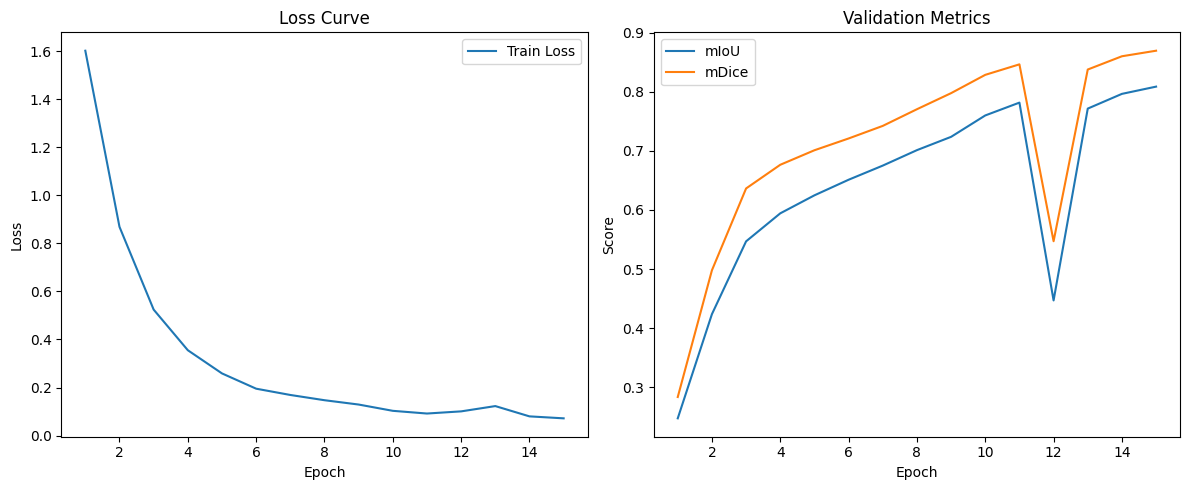

In [9]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

# Metrics plot
plt.subplot(1, 2, 2)
plt.plot(epochs, val_ious, label="mIoU")
plt.plot(epochs, val_dices, label="mDice")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Metrics")
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
torch.save(model.state_dict(), "model_final.pth")

In [11]:
checkpoint = {
    "epoch": epoch,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_losses": train_losses,
    "val_ious": val_ious,
    "val_dices": val_dices
}

torch.save(checkpoint, "checkpoint.pth")